In [41]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report

from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression


In [2]:
!pip install imblearn

Defaulting to user installation because normal site-packages is not writeable


In [3]:
df = pd.read_csv("df_encoded_output_smote_resampled.csv")
df.head()

,TBC1D3P5,SLCO1B1_y,CACTIN_y,SNORD112|ENSG00000252566.1,TET2,OR2M7_y,NTN1_y,SBNO2_y,CCDC109B_y,IL2_y,...,SF3A1_y,PDS5A_y,KCNJ12_y,ZNF57_y,AAED1,DYNC1LI2_y,RN7SKP137,AGE,GRADE,CLINICAL_STAGE
0,-1,0,-1,-1,-1,-1,0,0,-1,-1,...,-1,0,-1,0,0,-1,-1,44,2,2
1,-1,1,-1,-1,-1,1,-1,1,-1,-1,...,0,-1,-1,-1,-1,0,-1,52,2,2
2,-1,1,-1,-1,-1,-1,-1,-1,0,0,...,-1,-1,-1,-1,1,-1,0,59,2,1
3,-1,-1,-1,-1,-1,1,-1,-1,-1,-1,...,1,1,-1,1,-1,-1,-1,61,2,2
4,-1,0,-1,0,0,2,-1,-1,0,0,...,-1,0,-1,-1,0,-1,0,87,2,2


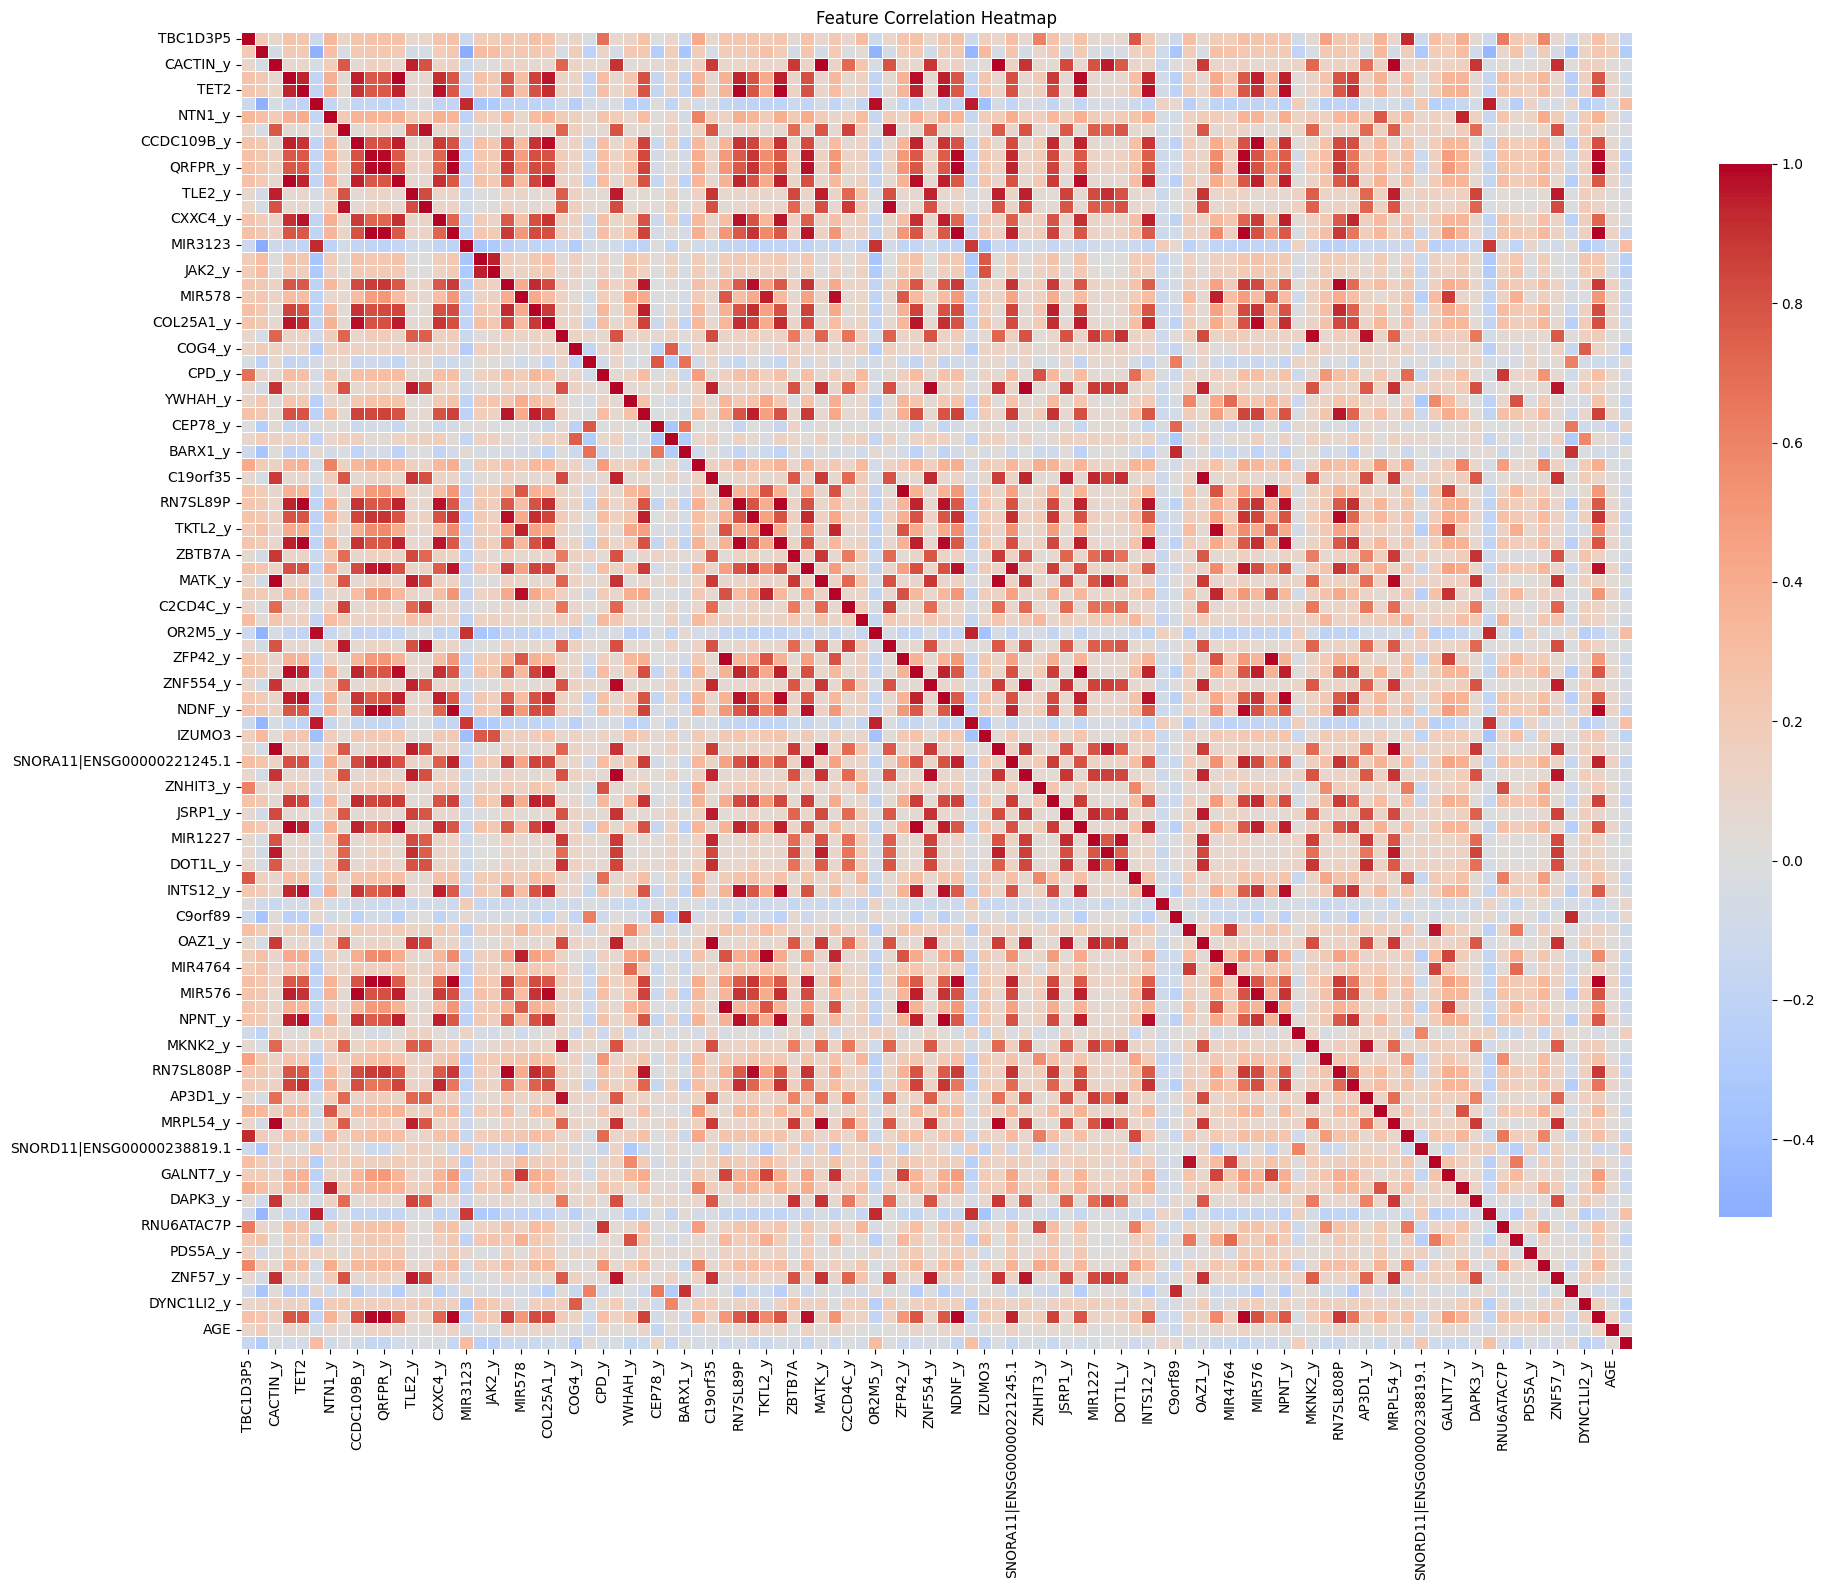

In [4]:
import seaborn as sns

import matplotlib.pyplot as plt

# Encode categorical columns before correlation
df_corr = df.copy()
for col in ['GRADE']:
    if df_corr[col].dtype == 'object':
        df_corr[col] = pd.factorize(df_corr[col])[0]

correlation_matrix = df_corr.drop(columns=['CLINICAL_STAGE']).corr()

# Create heatmap
plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0, 
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

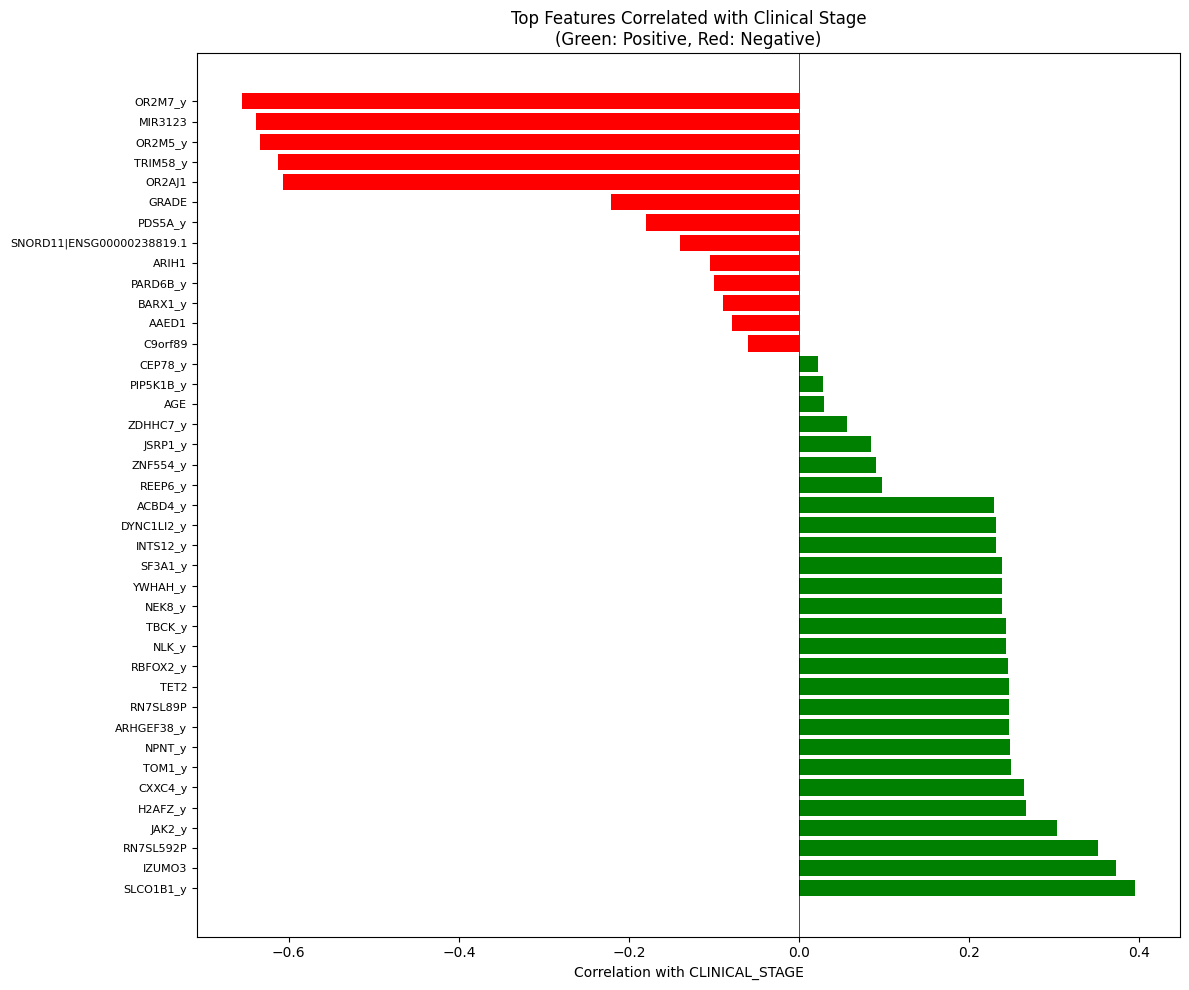


Top 20 Positively Correlated Features:
SLCO1B1_y     0.395589
IZUMO3        0.373286
RN7SL592P     0.352085
JAK2_y        0.303856
H2AFZ_y       0.266528
CXXC4_y       0.264580
TOM1_y        0.249963
NPNT_y        0.247755
ARHGEF38_y    0.247549
RN7SL89P      0.246822
TET2          0.246822
RBFOX2_y      0.245529
NLK_y         0.243553
TBCK_y        0.243022
NEK8_y        0.238829
YWHAH_y       0.238569
SF3A1_y       0.238452
INTS12_y      0.232250
DYNC1LI2_y    0.231363
ACBD4_y       0.228918
Name: CLINICAL_STAGE, dtype: float64

Top 20 Negatively Correlated Features:
REEP6_y                      0.097084
ZNF554_y                     0.091178
JSRP1_y                      0.084904
ZDHHC7_y                     0.056078
AGE                          0.029749
PIP5K1B_y                    0.028279
CEP78_y                      0.022496
C9orf89                     -0.059382
AAED1                       -0.079064
BARX1_y                     -0.088791
PARD6B_y                    -0.100008
ARIH1

In [5]:
# Calculate correlation of each feature with CLINICAL_STAGE
correlations = df_corr.corr()['CLINICAL_STAGE'].drop('CLINICAL_STAGE').sort_values(ascending=False)

# Get top 20 positively correlated and top 20 negatively correlated features
top_positive = correlations.head(20)
top_negative = correlations.tail(20)
top_features = pd.concat([top_positive, top_negative])

# Create visualization
plt.figure(figsize=(12, 10))
colors = ['green' if x > 0 else 'red' for x in top_features.values]
plt.barh(range(len(top_features)), top_features.values, color=colors)
plt.yticks(range(len(top_features)), top_features.index, fontsize=8)
plt.xlabel('Correlation with CLINICAL_STAGE')
plt.title('Top Features Correlated with Clinical Stage\n(Green: Positive, Red: Negative)')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

# Print correlation values
print("\nTop 20 Positively Correlated Features:")
print(top_positive)
print("\nTop 20 Negatively Correlated Features:")
print(top_negative)

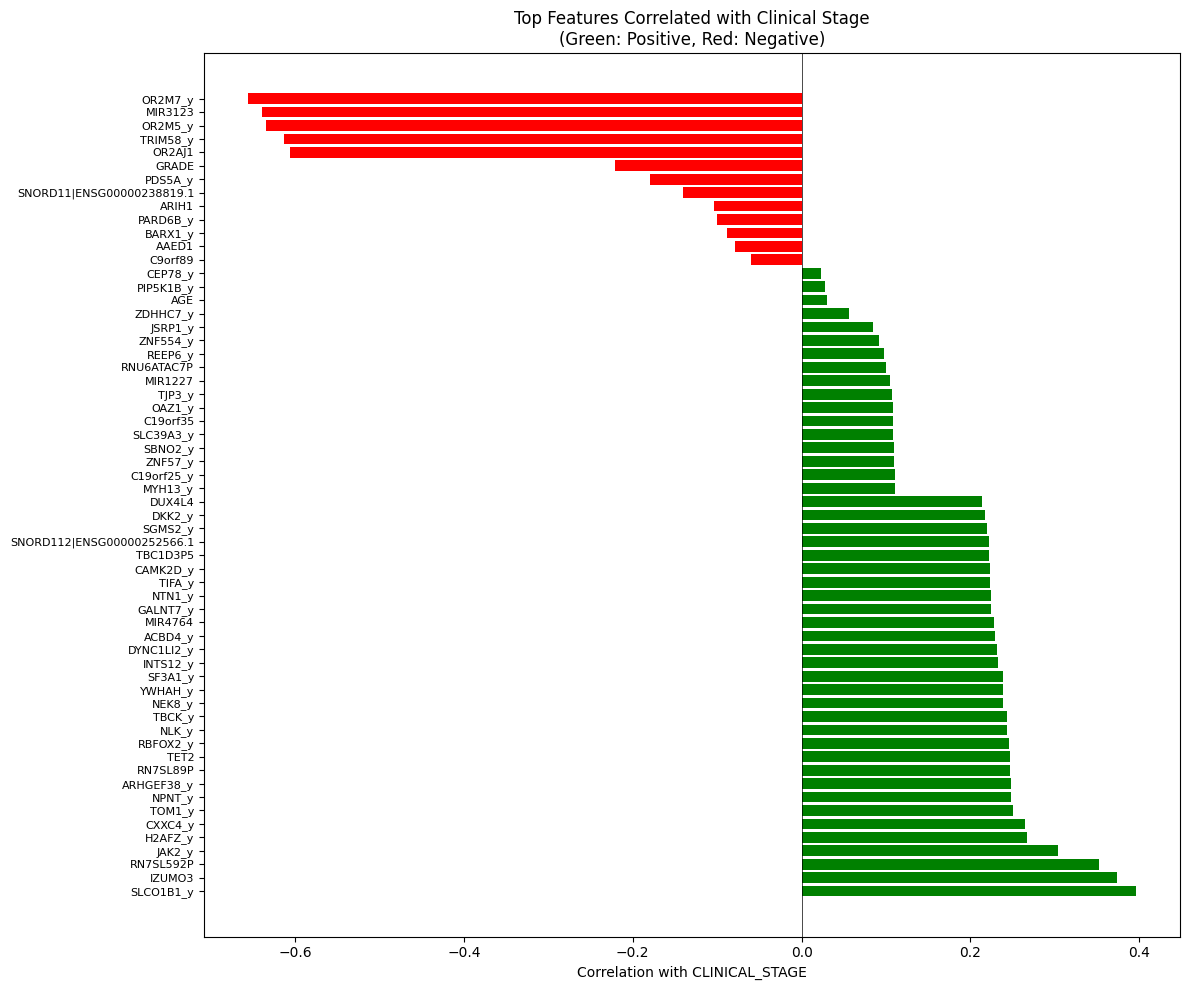


Top 30 Positively Correlated Features:
SLCO1B1_y                     0.395589
IZUMO3                        0.373286
RN7SL592P                     0.352085
JAK2_y                        0.303856
H2AFZ_y                       0.266528
CXXC4_y                       0.264580
TOM1_y                        0.249963
NPNT_y                        0.247755
ARHGEF38_y                    0.247549
RN7SL89P                      0.246822
TET2                          0.246822
RBFOX2_y                      0.245529
NLK_y                         0.243553
TBCK_y                        0.243022
NEK8_y                        0.238829
YWHAH_y                       0.238569
SF3A1_y                       0.238452
INTS12_y                      0.232250
DYNC1LI2_y                    0.231363
ACBD4_y                       0.228918
MIR4764                       0.227907
GALNT7_y                      0.224051
NTN1_y                        0.223789
TIFA_y                        0.222994
CAMK2D_y                

In [6]:
# Encode CLINICAL_STAGE for correlation calculation
if df_corr['CLINICAL_STAGE'].dtype == 'object':
	df_corr['CLINICAL_STAGE'] = pd.factorize(df_corr['CLINICAL_STAGE'])[0]

correlations = df_corr.corr()['CLINICAL_STAGE'].drop('CLINICAL_STAGE').sort_values(ascending=False)

# Get top 20 positively correlated and top 20 negatively correlated features
top_positive = correlations.head(30)
top_negative = correlations.tail(30)
top_features = pd.concat([top_positive, top_negative])

# Create visualization
plt.figure(figsize=(12, 10))
colors = ['green' if x > 0 else 'red' for x in top_features.values]
plt.barh(range(len(top_features)), top_features.values, color=colors)
plt.yticks(range(len(top_features)), top_features.index, fontsize=8)
plt.xlabel('Correlation with CLINICAL_STAGE')
plt.title('Top Features Correlated with Clinical Stage\n(Green: Positive, Red: Negative)')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

# Print correlation values
print("\nTop 30 Positively Correlated Features:")
print(top_positive)
print("\nTop 30 Negatively Correlated Features:")
print(top_negative)

In [7]:
print(df.columns.tolist())

['TBC1D3P5', 'SLCO1B1_y', 'CACTIN_y', 'SNORD112|ENSG00000252566.1', 'TET2', 'OR2M7_y', 'NTN1_y', 'SBNO2_y', 'CCDC109B_y', 'IL2_y', 'QRFPR_y', 'DKK2_y', 'TLE2_y', 'C19orf25_y', 'CXXC4_y', 'BBS7_y', 'MIR3123', 'RN7SL592P', 'JAK2_y', 'NDST4_y', 'MIR578', 'TIFA_y', 'COL25A1_y', 'RN7SL226P', 'COG4_y', 'PIP5K1B_y', 'CPD_y', 'SLC39A3_y', 'YWHAH_y', 'CAMK2D_y', 'CEP78_y', 'ZDHHC7_y', 'BARX1_y', 'SNORD3C', 'C19orf35', 'DUX4L4', 'RN7SL89P', 'MTRNR2L13', 'TKTL2_y', 'ARHGEF38_y', 'ZBTB7A', 'MAD2L1_y', 'MATK_y', 'RNA5SP170', 'C2CD4C_y', 'DHFR_y', 'OR2M5_y', 'REEP6_y', 'ZFP42_y', 'SGMS2_y', 'ZNF554_y', 'TBCK_y', 'NDNF_y', 'TRIM58_y', 'IZUMO3', 'GIPC3', 'SNORA11|ENSG00000221245.1', 'SGTA_y', 'ZNHIT3_y', 'ELOVL6_y', 'JSRP1_y', 'PAPSS1_y', 'MIR1227', 'TJP3_y', 'DOT1L_y', 'NEK8_y', 'INTS12_y', 'PARD6B_y', 'C9orf89', 'TOM1_y', 'OAZ1_y', 'TMA16_y', 'MIR4764', 'KIAA1109_y', 'MIR576', 'DUX4L2_y', 'NPNT_y', 'ARIH1', 'MKNK2_y', 'ACBD4_y', 'RN7SL808P', 'H2AFZ_y', 'AP3D1_y', 'MYH13_y', 'MRPL54_y', 'NLK_y', 'SNO

In [8]:
df.shape

(939, 103)

In [9]:
target_col = "CLINICAL_STAGE"   # change if needed

X = df.drop(columns=[target_col])
y = df[target_col]

In [10]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)
le.classes_   # check mapping


array([0, 1, 2, 3])

In [11]:
# Step 1: Train vs Temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

# Step 2: Validation vs Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,   # 50% of 30% = 15%
    random_state=42,
    stratify=y_temp
)

X_train.shape, X_val.shape, X_test.shape

((657, 102), (141, 102), (141, 102))

In [12]:
# Identify categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns
print(categorical_cols)


Index([], dtype='object')


In [13]:
# Using LabelEncoder for simplicity
from sklearn.preprocessing import LabelEncoder

X_encoded = X.copy()

for col in categorical_cols:
    le_col = LabelEncoder()
    X_encoded[col] = le_col.fit_transform(X_encoded[col])


In [14]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_encoded, y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)


In [16]:
from imblearn.over_sampling import SMOTE

# Set k_neighbors smaller than the smallest class size
sm = SMOTE(random_state=42, k_neighbors=1)
X_train_bal, y_train_bal = sm.fit_resample(X_train_scaled, y_train)


In [17]:
rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train_bal, y_train_bal)

rf_val_pred = rf.predict(X_val_scaled)
print("Random Forest (Validation):\n")
print(classification_report(y_val, rf_val_pred))

Random Forest (Validation):

              precision    recall  f1-score   support

           0       0.91      0.85      0.88        34
           1       0.85      0.83      0.84        35
           2       0.77      0.83      0.80        36
           3       0.81      0.81      0.81        36

    accuracy                           0.83       141
   macro avg       0.83      0.83      0.83       141
weighted avg       0.83      0.83      0.83       141



In [18]:
# ---- RANDOM FOREST TEST PREDICTION ----
from sklearn.metrics import classification_report, confusion_matrix
# Predict on the test set
rf_test_pred = rf.predict(X_test_scaled)

print("Random Forest (Test Results):\n")
print(classification_report(y_test, rf_test_pred))

print("Confusion Matrix (Test):")
print(confusion_matrix(y_test, rf_test_pred))



Random Forest (Test Results):

              precision    recall  f1-score   support

           0       0.81      0.88      0.85        34
           1       0.92      0.94      0.93        35
           2       0.80      0.76      0.78        37
           3       0.79      0.74      0.76        35

    accuracy                           0.83       141
   macro avg       0.83      0.83      0.83       141
weighted avg       0.83      0.83      0.83       141

Confusion Matrix (Test):
[[30  1  1  2]
 [ 1 33  1  0]
 [ 2  2 28  5]
 [ 4  0  5 26]]


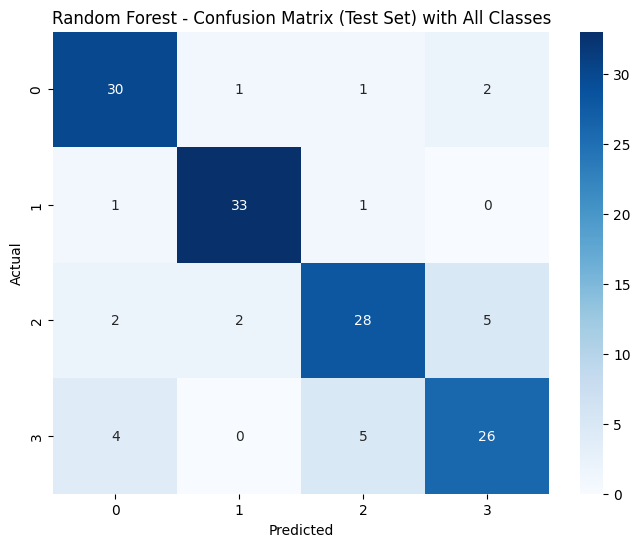

In [19]:
# Ensure all four stages (0–3) appear in the confusion matrix
labels = [0, 1, 2, 3]  # corresponds to class_names = ['I', 'II', 'III', 'IV']
class_names = le.classes_  # Get class names from the label encoder
cm_full = confusion_matrix(y_test, rf_test_pred, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_full, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Random Forest - Confusion Matrix (Test Set) with All Classes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [20]:


xgb = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train_bal, y_train_bal)
xgb_val_pred = xgb.predict(X_val_scaled)

print("XGBoost (Validation):\n")
print(classification_report(y_val, xgb_val_pred))


XGBoost (Validation):

              precision    recall  f1-score   support

           0       0.90      0.82      0.86        34
           1       0.76      0.91      0.83        35
           2       0.80      0.78      0.79        36
           3       0.94      0.86      0.90        36

    accuracy                           0.84       141
   macro avg       0.85      0.84      0.84       141
weighted avg       0.85      0.84      0.84       141



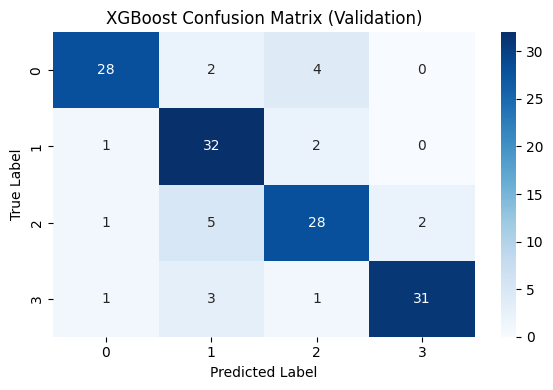

In [21]:
# ---- CONFUSION MATRIX FOR XGBOOST (VALIDATION) ----
# Note: Make sure cell 16 (XGBoost training) is executed first
import seaborn as sns
import matplotlib.pyplot as plt
labels = [0, 1, 2, 3]  # corresponds to class_names = ['I', 'II', 'III', 'IV']
cm_full = confusion_matrix(y_test, rf_test_pred, labels=labels)

# Generate predictions if not already available
xgb_val_pred = xgb.predict(X_val_scaled)
cm_xgb = confusion_matrix(y_val, xgb_val_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("XGBoost Confusion Matrix (Validation)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


In [22]:
lgbm = LGBMClassifier(
    n_estimators=400,
    learning_rate=0.05,
    random_state=42
)

lgbm.fit(X_train_bal, y_train_bal)
lgbm_val_pred = lgbm.predict(X_val_scaled)

print("LightGBM (Validation):\n")
print(classification_report(y_val, lgbm_val_pred))


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001864 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 564
[LightGBM] [Info] Number of data points in the train set: 676, number of used features: 102
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [23]:
svm_rbf = SVC(kernel="rbf", probability=True, random_state=42)
svm_rbf.fit(X_train_bal, y_train_bal)

svm_val_pred = svm_rbf.predict(X_val_scaled)

print("SVM (Validation):\n")
print(classification_report(y_val, svm_val_pred))


SVM (Validation):

              precision    recall  f1-score   support

           0       0.88      0.82      0.85        34
           1       0.91      0.86      0.88        35
           2       0.78      0.78      0.78        36
           3       0.80      0.89      0.84        36

    accuracy                           0.84       141
   macro avg       0.84      0.84      0.84       141
weighted avg       0.84      0.84      0.84       141



In [24]:
logreg = LogisticRegression(max_iter=5000)
logreg.fit(X_train_bal, y_train_bal)

log_val_pred = logreg.predict(X_val_scaled)

print("Logistic Regression (Validation):\n")
print(classification_report(y_val, log_val_pred))


Logistic Regression (Validation):

              precision    recall  f1-score   support

           0       0.80      0.82      0.81        34
           1       0.81      0.83      0.82        35
           2       0.74      0.72      0.73        36
           3       0.86      0.83      0.85        36

    accuracy                           0.80       141
   macro avg       0.80      0.80      0.80       141
weighted avg       0.80      0.80      0.80       141



In [25]:
final_test_pred = xgb.predict(X_test_scaled)

print("Final Test Performance (XGBoost):\n")
print(classification_report(y_test, final_test_pred))


Final Test Performance (XGBoost):

              precision    recall  f1-score   support

           0       0.86      0.91      0.89        34
           1       0.89      0.94      0.92        35
           2       0.86      0.84      0.85        37
           3       0.88      0.80      0.84        35

    accuracy                           0.87       141
   macro avg       0.87      0.87      0.87       141
weighted avg       0.87      0.87      0.87       141



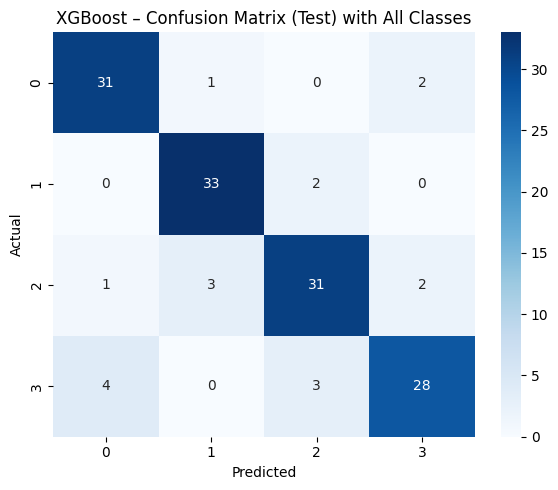

In [26]:
#---Confusion matrix with all classes (0,1,2,3) for XGBoost test set
labels = [0, 1, 2, 3]

# Fallback in case class_names is not yet defined
class_names = class_names if 'class_names' in locals() else (
    le.classes_ if 'le' in locals() else [str(l) for l in labels]
)

cm_xgb_full = confusion_matrix(y_test, final_test_pred, labels=labels)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_xgb_full, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("XGBoost – Confusion Matrix (Test) with All Classes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

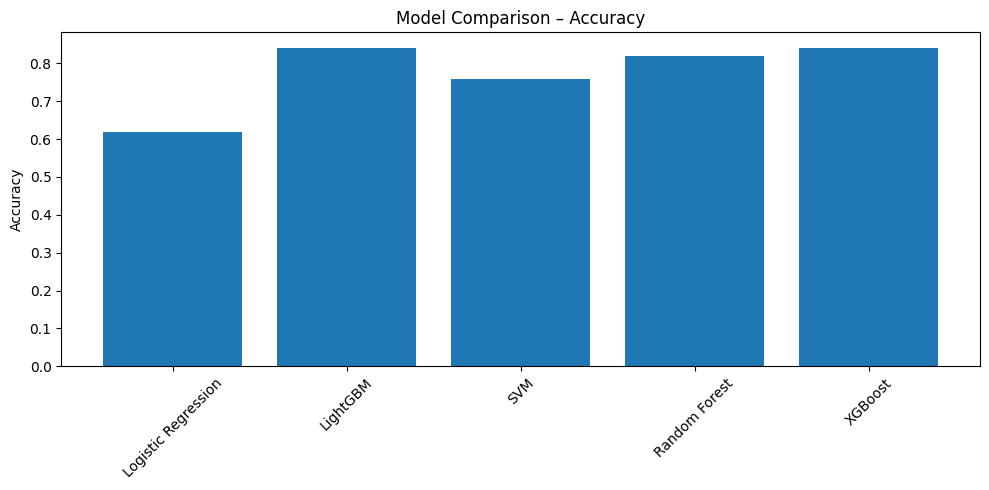

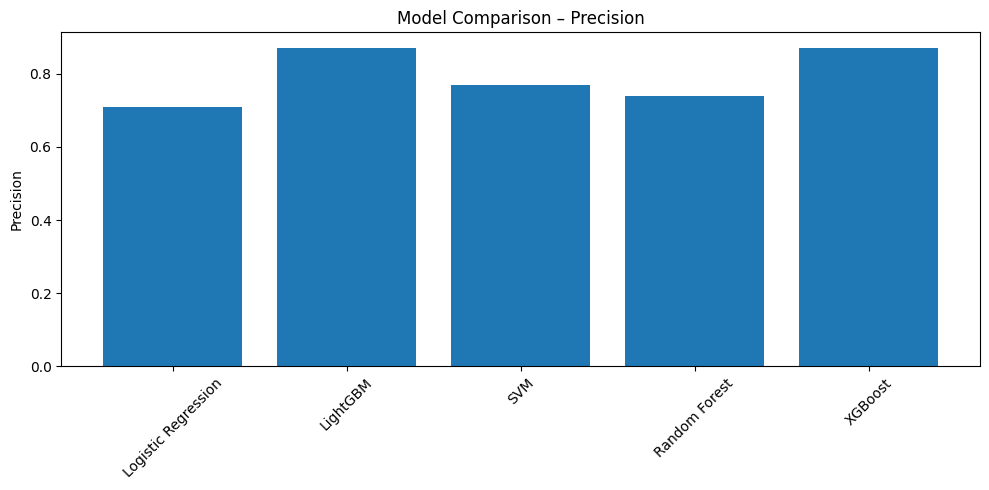

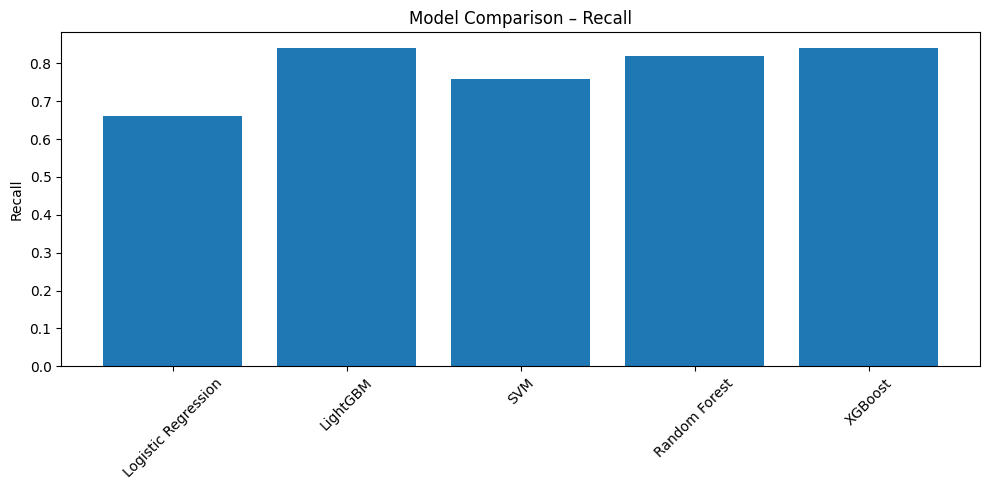

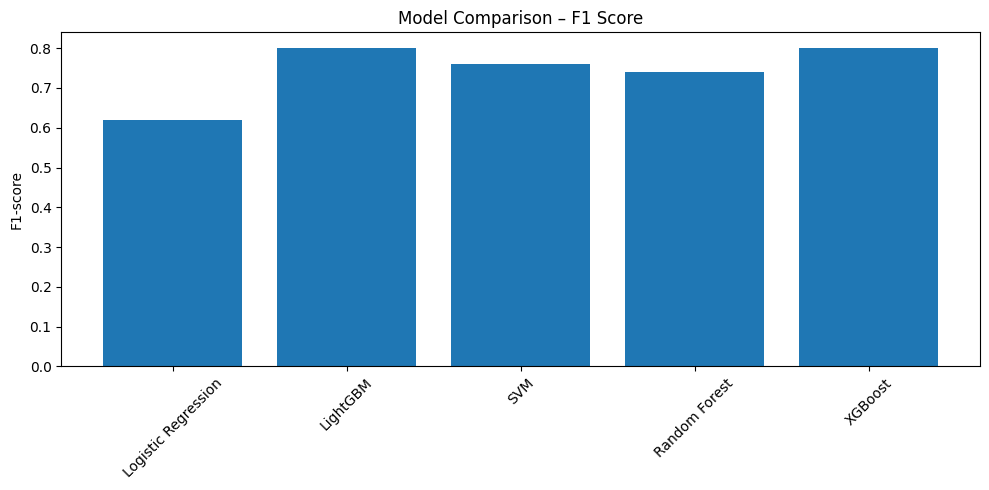

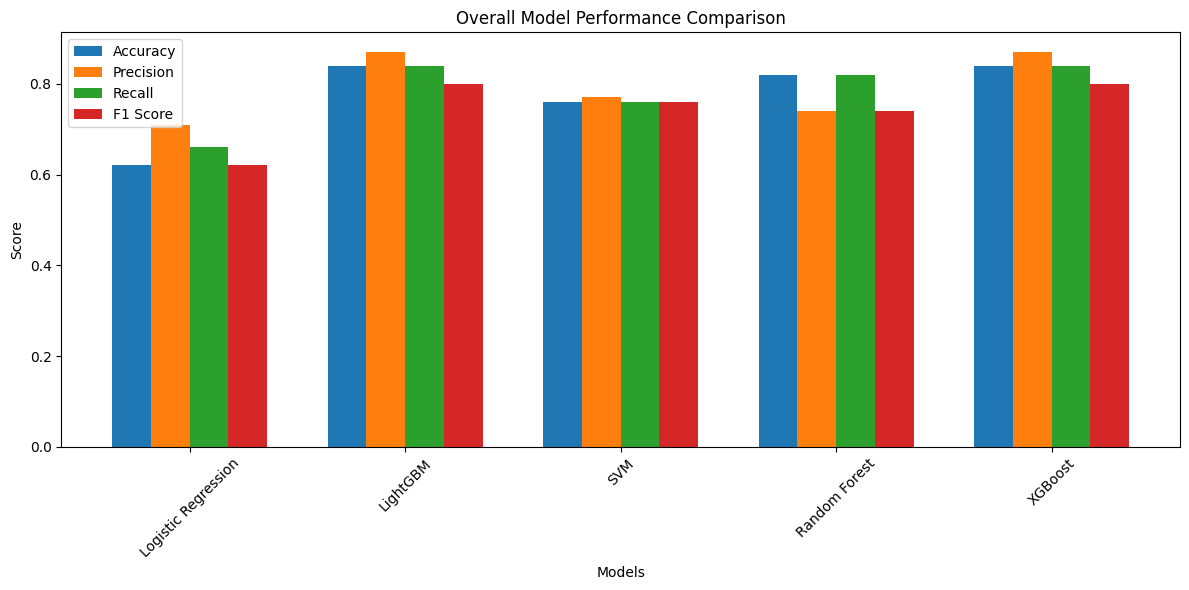

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# ===========================
# 1. STORE MODEL METRICS
# Replace values with your actual results
# ===========================

metrics = {
    "Logistic Regression": {"accuracy": 0.62, "precision": 0.71, "recall": 0.66, "f1": 0.62},
    "LightGBM": {"accuracy": 0.84, "precision": 0.87, "recall": 0.84, "f1": 0.80},
    "SVM": {"accuracy": 0.76, "precision": 0.77, "recall": 0.76, "f1": 0.76},
    "Random Forest": {"accuracy": 0.82, "precision": 0.74, "recall": 0.82, "f1": 0.74},
    "XGBoost": {"accuracy": 0.84, "precision": 0.87, "recall": 0.84, "f1": 0.80}
}

models = list(metrics.keys())

# Extract values
accuracy = [metrics[m]["accuracy"] for m in models]
precision = [metrics[m]["precision"] for m in models]
recall = [metrics[m]["recall"] for m in models]
f1 = [metrics[m]["f1"] for m in models]

# ===========================
# 2. BAR CHART – ACCURACY
# ===========================

plt.figure(figsize=(10, 5))
plt.bar(models, accuracy)
plt.title("Model Comparison – Accuracy")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ===========================
# 3. BAR CHART – PRECISION
# ===========================

plt.figure(figsize=(10, 5))
plt.bar(models, precision)
plt.title("Model Comparison – Precision")
plt.ylabel("Precision")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ===========================
# 4. BAR CHART – RECALL
# ===========================

plt.figure(figsize=(10, 5))
plt.bar(models, recall)
plt.title("Model Comparison – Recall")
plt.ylabel("Recall")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ===========================
# 5. BAR CHART – F1-SCORE
# ===========================

plt.figure(figsize=(10, 5))
plt.bar(models, f1)
plt.title("Model Comparison – F1 Score")
plt.ylabel("F1-score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ===========================
# 6. GROUPED BAR CHART (All Metrics Together)
# ===========================

x = np.arange(len(models))
width = 0.18

plt.figure(figsize=(12, 6))
plt.bar(x - 1.5*width, accuracy, width, label="Accuracy")
plt.bar(x - 0.5*width, precision, width, label="Precision")
plt.bar(x + 0.5*width, recall, width, label="Recall")
plt.bar(x + 1.5*width, f1, width, label="F1 Score")

plt.xlabel("Models")
plt.ylabel("Score")
plt.title("Overall Model Performance Comparison")
plt.xticks(x, models, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


In [28]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Use your trained XGBoost model
model = xgb  # already trained on training set

# Create SHAP explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train_scaled)

# For multi-class, shap_values is a list (one array per class)

C:\Users\HP Laptop 15\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [29]:
# shap_values is a list of arrays (one per class)
# Each array has shape (n_samples, n_features)

# Compute mean absolute SHAP for each feature across all classes and all samples
mean_abs_shap = np.mean(np.array([np.abs(sv) for sv in shap_values]), axis=(0, 1))

# Now mean_abs_shap is 1D array of length n_features
print(len(mean_abs_shap), len(X.columns))  # Should match

4 102


In [30]:
# Ensure X_train_scaled is a DataFrame with correct column names
X_train_df = pd.DataFrame(X_train_scaled, columns=X.columns)

In [31]:
import shap
import numpy as np

explainer = shap.TreeExplainer(xgb)  # your trained XGBoost
shap_values = explainer.shap_values(X_train_df)  # pass DataFrame with column names

In [32]:
# Convert list of arrays to a single 3D array: (n_classes, n_samples, n_features)
shap_array = np.array([np.abs(sv) for sv in shap_values])

# Take mean across classes (axis=0) and samples (axis=1)
mean_abs_shap = np.mean(shap_array, axis=(0, 1))  # shape = (n_features,)

In [33]:
print(len(mean_abs_shap), len(X_train_df.columns))  # should be equal

4 102


In [34]:
# If X_train_scaled corresponds to 100 features, use only those 100 columns
X_train_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)  # columns must match training features
shap_values = explainer.shap_values(X_train_df)


In [35]:
# Ensure only 102 features (used in training) are passed
X_train_shap = pd.DataFrame(X_train_scaled, columns=X_train.columns)  # 102 columns


In [36]:
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_train_shap)  # only 102 features

In [37]:
if isinstance(shap_values, list):  # multi-class
    shap_array = np.stack([np.abs(sv) for sv in shap_values], axis=0)  # (classes, samples, features)
    mean_abs_shap = shap_array.mean(axis=(0, 1))  # shape: (102,)
else:  # binary
    mean_abs_shap = np.abs(shap_values).mean(axis=0)

# Flatten to 1D
mean_abs_shap = mean_abs_shap.flatten()
print(mean_abs_shap.shape, len(X_train_shap.columns))  # should be (102, 102)


(408,) 102


In [38]:
import pandas as pd

# Load your dataset
df_final = pd.read_csv("df_encoded_output_smote_resampled.csv")

# Show all column names
print(df_final.columns.tolist())

# Optionally, check first few rows to identify target
print(df_final.head())

['TBC1D3P5', 'SLCO1B1_y', 'CACTIN_y', 'SNORD112|ENSG00000252566.1', 'TET2', 'OR2M7_y', 'NTN1_y', 'SBNO2_y', 'CCDC109B_y', 'IL2_y', 'QRFPR_y', 'DKK2_y', 'TLE2_y', 'C19orf25_y', 'CXXC4_y', 'BBS7_y', 'MIR3123', 'RN7SL592P', 'JAK2_y', 'NDST4_y', 'MIR578', 'TIFA_y', 'COL25A1_y', 'RN7SL226P', 'COG4_y', 'PIP5K1B_y', 'CPD_y', 'SLC39A3_y', 'YWHAH_y', 'CAMK2D_y', 'CEP78_y', 'ZDHHC7_y', 'BARX1_y', 'SNORD3C', 'C19orf35', 'DUX4L4', 'RN7SL89P', 'MTRNR2L13', 'TKTL2_y', 'ARHGEF38_y', 'ZBTB7A', 'MAD2L1_y', 'MATK_y', 'RNA5SP170', 'C2CD4C_y', 'DHFR_y', 'OR2M5_y', 'REEP6_y', 'ZFP42_y', 'SGMS2_y', 'ZNF554_y', 'TBCK_y', 'NDNF_y', 'TRIM58_y', 'IZUMO3', 'GIPC3', 'SNORA11|ENSG00000221245.1', 'SGTA_y', 'ZNHIT3_y', 'ELOVL6_y', 'JSRP1_y', 'PAPSS1_y', 'MIR1227', 'TJP3_y', 'DOT1L_y', 'NEK8_y', 'INTS12_y', 'PARD6B_y', 'C9orf89', 'TOM1_y', 'OAZ1_y', 'TMA16_y', 'MIR4764', 'KIAA1109_y', 'MIR576', 'DUX4L2_y', 'NPNT_y', 'ARIH1', 'MKNK2_y', 'ACBD4_y', 'RN7SL808P', 'H2AFZ_y', 'AP3D1_y', 'MYH13_y', 'MRPL54_y', 'NLK_y', 'SNO

In [39]:
# Features used for modeling
final_features = df_final.columns.drop('CLINICAL_STAGE').tolist()
len(final_features)  # should be 102

102

In [42]:
from sklearn.model_selection import train_test_split

# Features and target
X = df_final[final_features]
y = df_final['CLINICAL_STAGE']

# First split: train + temp (val + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# Second split: validation and test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

# Check shapes
print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)


Train: (657, 102) (657,)
Validation: (141, 102) (141,)
Test: (141, 102) (141,)


In [43]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on training set
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# Optional: convert back to DataFrame to keep column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_val_scaled   = pd.DataFrame(X_val_scaled, columns=X_val.columns, index=X_val.index)
X_test_scaled  = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

In [ ]:
print(X_train_scaled.head())
print(X_val_scaled.head())
print(X_test_scaled.head())

     TBC1D3P5  SLCO1B1_y  CACTIN_y  SNORD112|ENSG00000252566.1      TET2  \
803  1.396861  -0.057557  2.460081                    1.319666  1.347571   
593 -0.472258   1.162272 -0.251787                    1.319666  1.347571   
390 -0.472258  -1.277386 -0.251787                   -0.442571 -0.433826   
159 -0.472258  -0.057557 -0.251787                   -0.442571 -0.433826   
650 -0.472258  -0.057557 -0.251787                   -2.204807 -2.215223   

      OR2M7_y    NTN1_y   SBNO2_y  CCDC109B_y     IL2_y  ...  RNU6ATAC7P  \
803  0.169201  3.148218  2.681753    1.249244  1.254959  ...    -0.33935   
593  0.169201 -0.502937 -0.211370    1.249244  1.254959  ...    -0.33935   
390  1.327170 -0.502937 -0.211370   -0.464228 -0.545277  ...    -0.33935   
159  0.169201 -0.502937 -0.211370   -0.464228 -0.545277  ...    -0.33935   
650  0.169201 -0.502937 -0.211370   -2.177701 -0.545277  ...    -0.33935   

      SF3A1_y   PDS5A_y  KCNJ12_y   ZNF57_y     AAED1  DYNC1LI2_y  RN7SKP137  \
803  0

In [44]:
from imblearn.over_sampling import SMOTE
import pandas as pd

# Initialize SMOTE
smote = SMOTE(random_state=42, k_neighbors=1)  # k_neighbors can be 1 if minority classes are tiny

# Fit on training data only
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

# Check class distribution
print(pd.Series(y_train_bal).value_counts())


CLINICAL_STAGE
3    169
1    169
0    169
2    169
Name: count, dtype: int64


In [45]:
models = {
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42),
    "LightGBM": LGBMClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42)
}

In [46]:
results_val = {}
for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    y_pred_val = model.predict(X_val_scaled)
    print(f"\n{name} Validation Report:")
    print(classification_report(y_val, y_pred_val))
    results_val[name] = model

C:\Users\HP Laptop 15\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [06:25:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost Validation Report:
              precision    recall  f1-score   support

           0       0.88      0.82      0.85        34
           1       0.78      0.89      0.83        35
           2       0.80      0.78      0.79        36
           3       0.94      0.89      0.91        36

    accuracy                           0.84       141
   macro avg       0.85      0.84      0.84       141
weighted avg       0.85      0.84      0.84       141


RandomForest Validation Report:
              precision    recall  f1-score   support

           0       0.91      0.85      0.88        34
           1       0.83      0.83      0.83        35
           2       0.76      0.81      0.78        36
           3       0.81      0.81      0.81        36

    accuracy                           0.82       141
   macro avg       0.83      0.82      0.82       141
weighted avg       0.82      0.82      0.82       141

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhea

In [47]:
best_model = results_val["XGBoost"]

In [48]:
y_pred_test = best_model.predict(X_test_scaled)
print("\nXGBoost Test Report:")
print(classification_report(y_test, y_pred_test))


XGBoost Test Report:
              precision    recall  f1-score   support

           0       0.86      0.88      0.87        34
           1       0.94      0.94      0.94        35
           2       0.84      0.84      0.84        37
           3       0.82      0.80      0.81        35

    accuracy                           0.87       141
   macro avg       0.87      0.87      0.87       141
weighted avg       0.87      0.87      0.87       141



In [ ]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_train_scaled)

In [49]:
if isinstance(shap_values, list):  # multi-class
    shap_array = np.stack([np.abs(sv) for sv in shap_values], axis=0)
    mean_abs_shap = shap_array.mean(axis=(0, 1))  # mean across classes and samples
else:
    mean_abs_shap = np.abs(shap_values).mean(axis=0)

In [50]:
feature_importance = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'mean_abs_shap': mean_abs_shap.mean(axis=1) # Average across the class dimension
})

# Sort and select top 30 biomarkers
feature_importance_sorted = feature_importance.sort_values(by='mean_abs_shap', ascending=False)
top30_features = feature_importance_sorted.head(30)['feature'].tolist()
print("\nTop 30 Biomarkers:\n", feature_importance_sorted.head(30))


Top 30 Biomarkers:
                        feature  mean_abs_shap
100                        AGE       0.657747
101                      GRADE       0.408763
1                    SLCO1B1_y       0.318937
5                      OR2M7_y       0.258413
16                     MIR3123       0.226302
54                      IZUMO3       0.145938
67                    PARD6B_y       0.139173
94                     PDS5A_y       0.137211
25                   PIP5K1B_y       0.127836
86   SNORD11|ENSG00000238819.1       0.114051
93                     SF3A1_y       0.108538
18                      JAK2_y       0.107018
83                     MYH13_y       0.105042
31                    ZDHHC7_y       0.103396
65                      NEK8_y       0.101891
17                   RN7SL592P       0.099134
30                     CEP78_y       0.093073
35                      DUX4L4       0.089282
97                       AAED1       0.086444
24                      COG4_y       0.085647
77           

C:\Users\HP Laptop 15\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [06:26:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


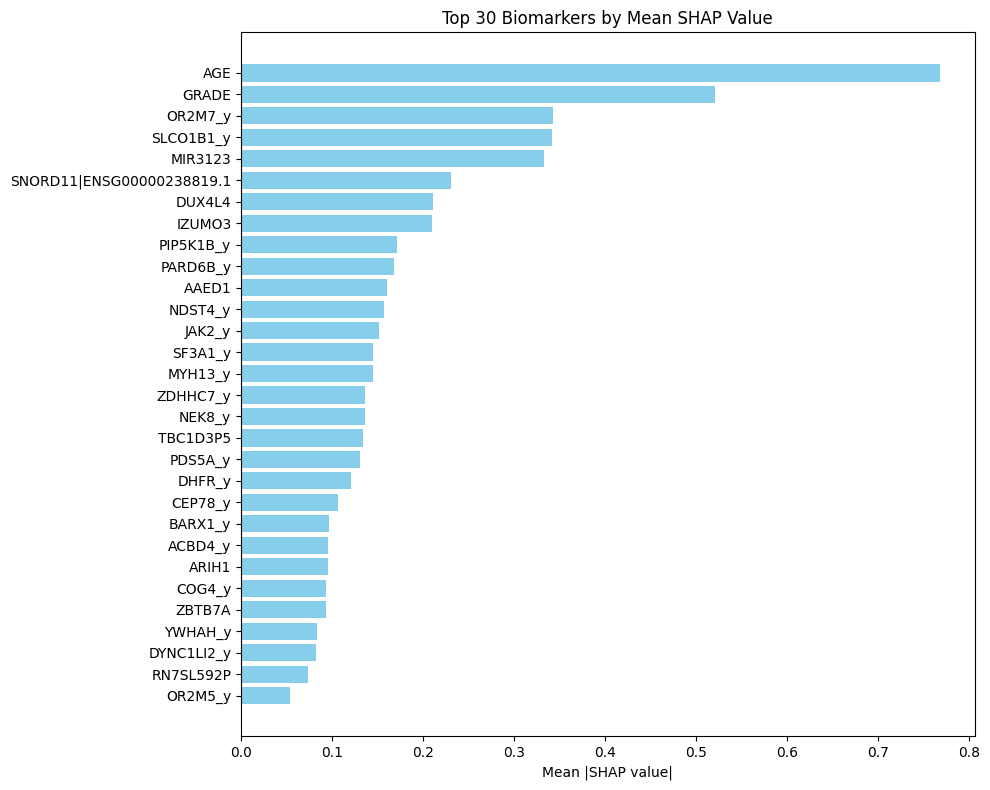

In [51]:
import shap
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd # Ensure pandas is imported

# 1. Prepare the top features from the balanced training set
#    X_train_bal has 672 samples and 102 features
#    top30_features is a list of 30 feature names
X_train_bal_top = X_train_bal[top30_features]

# 2. Retrain best_model with the top 30 features from the balanced training set
#    This step is crucial and was failing previously due to sample mismatch.
best_model.fit(X_train_bal_top, y_train_bal)

# 3. Create SHAP explainer using the retrained model
#    Use the model instance directly for TreeExplainer
explainer = shap.TreeExplainer(best_model)

# 4. Compute SHAP values on the data used for retraining (X_train_bal_top)
shap_values = explainer.shap_values(X_train_bal_top)

# 5. Multi-class: compute mean absolute SHAP per feature across classes and samples
if isinstance(shap_values, list):
    # shap_values is a list of arrays, each of shape (n_samples, n_features)
    # Stack them to get (n_classes, n_samples, n_features)
    shap_abs_stacked = np.stack([np.abs(sv) for sv in shap_values], axis=0)
    # Take mean over classes (axis=0) and samples (axis=1) to get a 1D array of shape (n_features,)
    mean_shap_per_feature = np.mean(shap_abs_stacked, axis=(0, 1))
else:
    # If shap_values is a single array, it's typically (n_samples, n_features) for binary
    # or (n_samples, n_features, n_classes) for multi-class depending on SHAP version/model.
    shap_abs = np.abs(shap_values)
    if shap_abs.ndim == 3: # Handles (n_samples, n_features, n_classes) structure
        # Average over samples (axis=0) and classes (axis=2) to get one value per feature
        mean_shap_per_feature = np.mean(shap_abs, axis=(0, 2))
    elif shap_abs.ndim == 2: # Handles (n_samples, n_features) for binary classification
        # Average over samples (axis=0) to get one value per feature
        mean_shap_per_feature = np.mean(shap_abs, axis=0)
    else:
        raise ValueError(f"Unexpected shap_values dimension: {shap_abs.ndim}")

# 6. Create feature importance DataFrame
feature_importance = pd.DataFrame({
    'feature': top30_features, # Use top30_features which are the columns of X_train_bal_top
    'mean_abs_shap': mean_shap_per_feature
})

# 7. Sort features
feature_importance = feature_importance.sort_values(by='mean_abs_shap', ascending=True)

# 8. Plot horizontal bar chart
plt.figure(figsize=(10,8))
plt.barh(feature_importance['feature'], feature_importance['mean_abs_shap'], color='skyblue')
plt.xlabel("Mean |SHAP value|")
plt.title("Top 30 Biomarkers by Mean SHAP Value")
plt.tight_layout()
plt.show()


In [52]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE

# Load dataset
df = pd.read_csv("final_dataset.csv")

# Encode categorical columns (GRADE and CLINICAL_STAGE)
df['GRADE'] = df['GRADE'].replace(['not available', None], 'Unknown')
df['CLINICAL_STAGE'] = df['CLINICAL_STAGE'].replace(['not available', None], 'Unknown')

le_grade = LabelEncoder()
df['GRADE'] = le_grade.fit_transform(df['GRADE'])

le_stage = LabelEncoder()
df['CLINICAL_STAGE'] = le_stage.fit_transform(df['CLINICAL_STAGE'])

# Separate features and target
target_col = 'CLINICAL_STAGE'
feature_cols = [c for c in df.columns if c != target_col]

X = df[feature_cols]
y = df[target_col]

# Fill missing values (simple numeric fill for now)
X = X.fillna(0)


In [53]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)


In [54]:
top100_features = X_train_bal.columns[:100].tolist()

In [55]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_val_scaled   = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)


In [56]:
smote = SMOTE(random_state=42, k_neighbors=1)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)


In [57]:
top100_features = X_train_bal.columns[:100].tolist()

In [58]:
import numpy as np
# create X_train_100 from the balanced training set using top100_features
X_train_100 = X_train_bal[top100_features]

# exclude AGE and GRADE if present
features_for_shap = [f for f in X_train_100.columns if f not in ['AGE', 'GRADE']]

X_train_shap = X_train_100[features_for_shap]
X_train_shap_np = X_train_shap.values.astype(np.float32)
X_train_shap = X_train_100[features_for_shap]
X_train_shap_np = X_train_shap.values.astype(np.float32)

In [59]:
# 1. Select the top 100 biomarker features (using the correctly defined top100_features)
X_100 = df[top100_features]
y = df['CLINICAL_STAGE']

# 3. Split into train and test
from sklearn.model_selection import train_test_split

X_train_100, X_test_100, y_train_100, y_test_100 = train_test_split(
    X_100, y, test_size=0.2, random_state=42, stratify=y
)
# Removed redundant X_train_shap, features_for_shap definitions from here

In [60]:
import shap
import numpy as np
import xgboost as xgb

# Ensure X_train_100 and y_train_100 are defined from previous steps
# Redefine features for SHAP and X_train_shap here for consistency
features_for_shap = [f for f in X_train_100.columns if f not in ['AGE', 'GRADE']]
X_train_shap = X_train_100[features_for_shap]
X_train_shap_np = X_train_shap.values.astype(np.float32)

model = xgb.XGBClassifier().fit(X_train_shap, y_train_100)

# Create SHAP explainer
explainer = shap.TreeExplainer(model)

In [61]:
# SHAP values for training set
shap_values = explainer.shap_values(X_train_shap)


In [62]:
X_train_shap = X_train_100[features_for_shap]


In [63]:
# Select only the 100 biomarkers + target
biomarker_cols = [col for col in X_train_100.columns if col not in ['AGE', 'GRADE']]

# Filter training data
X_train_shap = X_train_100[biomarker_cols]

# Convert to float32
X_train_shap_np = X_train_shap.values.astype(np.float32)


In [64]:
# Assuming explainer and X_train_shap_np are correctly defined from previous steps
shap_values = explainer.shap_values(X_train_shap_np)

In [66]:
# Show top 10 biomarkers by mean |SHAP| value
biomarker_importance = pd.DataFrame({
    "biomarker": top30_features,
    "mean_abs_shap": mean_shap_per_feature
}).sort_values("mean_abs_shap", ascending=False)

top10_biomarkers = biomarker_importance.head(10)
print(top10_biomarkers)

                    biomarker  mean_abs_shap
0                         AGE       0.767496
1                       GRADE       0.520271
3                     OR2M7_y       0.342764
2                   SLCO1B1_y       0.342008
4                     MIR3123       0.333079
9   SNORD11|ENSG00000238819.1       0.230591
17                     DUX4L4       0.211190
5                      IZUMO3       0.209379
8                   PIP5K1B_y       0.171207
6                    PARD6B_y       0.167974


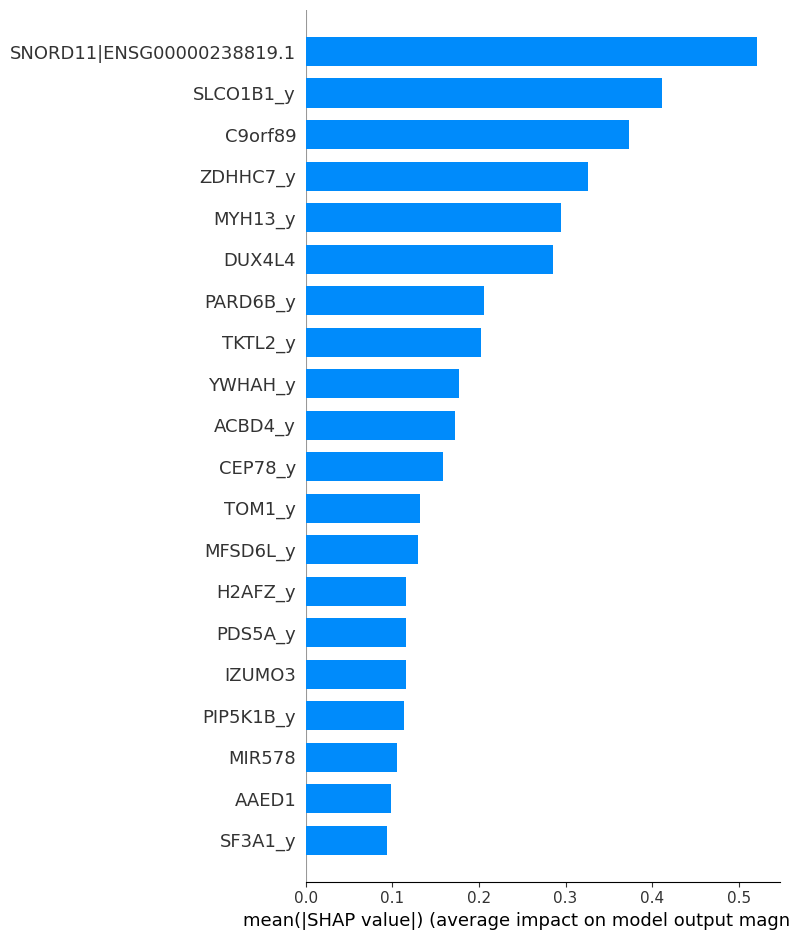

In [67]:
class_index = 1   # 0, 1, 2, ... depending on number of classes

# Correctly index shap_values for multi-class output
# Assumes shap_values is a list of arrays (n_samples, n_features) or a 3D array (n_samples, n_features, n_classes)
if isinstance(shap_values, list):
    shap_values_for_plot = shap_values[class_index]
else:
    shap_values_for_plot = shap_values[:, :, class_index]

# Ensure feature counts match before plotting
if shap_values_for_plot.shape[1] != X_train_shap.shape[1]:
    raise AssertionError(
        f"Shape mismatch: shap_values_for_plot have {shap_values_for_plot.shape[1]} features, "
        f"but X_train_shap has {X_train_shap.shape[1]} features. "
        "Please ensure all preceding cells defining X_train_shap, training the model, "
        "and calculating shap_values are run in order."
    )

shap.summary_plot(
    shap_values_for_plot,
    X_train_shap,
    plot_type="bar",
    feature_names=features_for_shap
)

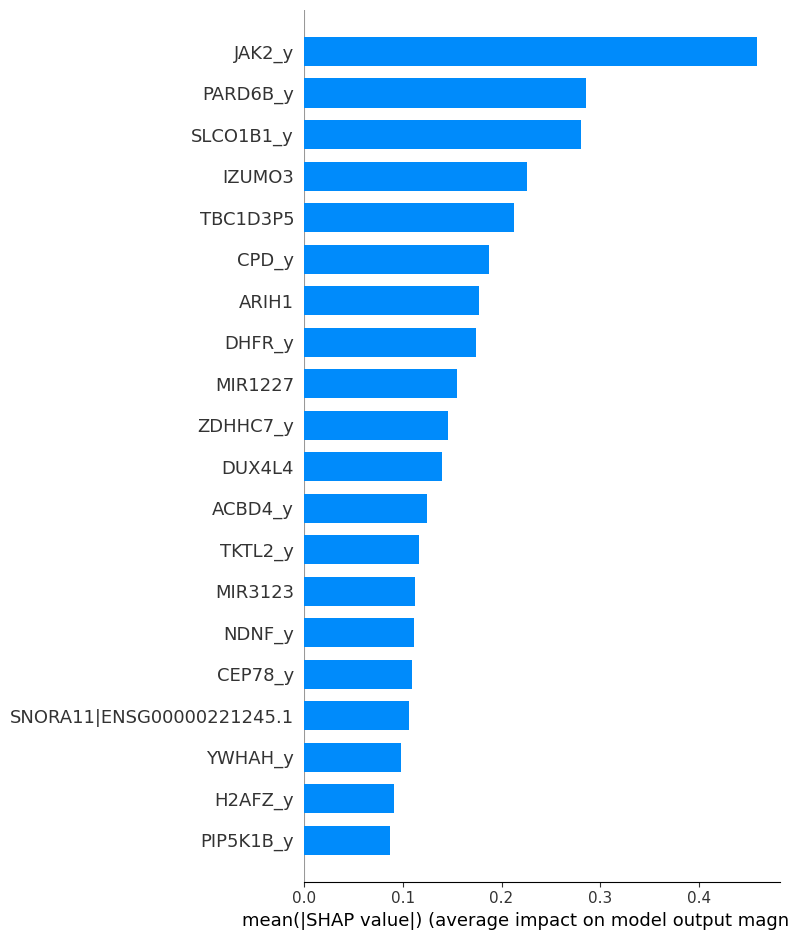

In [68]:
class_index = 2  # 0, 1, 2, ... depending on number of classes

# Correctly index shap_values for multi-class output
# Assumes shap_values is a list of arrays (n_samples, n_features) or a 3D array (n_samples, n_features, n_classes)
if isinstance(shap_values, list):
    shap_values_for_plot = shap_values[class_index]
else:
    shap_values_for_plot = shap_values[:, :, class_index]

# Ensure feature counts match before plotting
if shap_values_for_plot.shape[1] != X_train_shap.shape[1]:
    raise AssertionError(
        f"Shape mismatch: shap_values_for_plot have {shap_values_for_plot.shape[1]} features, "
        f"but X_train_shap has {X_train_shap.shape[1]} features. "
        "Please ensure all preceding cells defining X_train_shap, training the model, "
        "and calculating shap_values are run in order."
    )

shap.summary_plot(
    shap_values_for_plot,
    X_train_shap,
    plot_type="bar",
    feature_names=features_for_shap
)

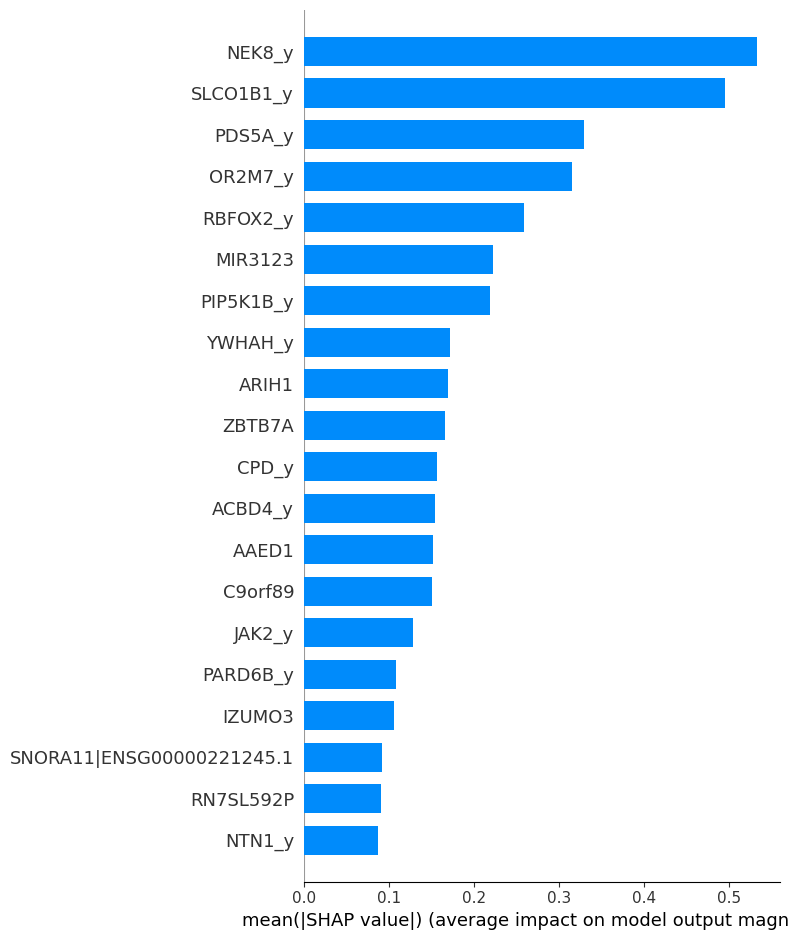

In [69]:
class_index = 3   # 0, 1, 2, ... depending on number of classes

# Correctly index shap_values for multi-class output
# Assumes shap_values is a list of arrays (n_samples, n_features) or a 3D array (n_samples, n_features, n_classes)
if isinstance(shap_values, list):
    shap_values_for_plot = shap_values[class_index]
else:
    shap_values_for_plot = shap_values[:, :, class_index]

# Ensure feature counts match before plotting
if shap_values_for_plot.shape[1] != X_train_shap.shape[1]:
    raise AssertionError(
        f"Shape mismatch: shap_values_for_plot have {shap_values_for_plot.shape[1]} features, "
        f"but X_train_shap has {X_train_shap.shape[1]} features. "
        "Please ensure all preceding cells defining X_train_shap, training the model, "
        "and calculating shap_values are run in order."
    )

shap.summary_plot(
    shap_values_for_plot,
    X_train_shap,
    plot_type="bar",
    feature_names=features_for_shap
)

In [ ]:
# ========== Export artifacts ==========
import joblib
import json
import pandas as pd

# Replace these variable names with the ones from your notebook:
# best_model: trained XGBoost model (sklearn API)
# scaler: trained StandardScaler
# final_features: list of feature names used for training (100 or 30)
# le_stage: LabelEncoder used to transform CLINICAL_STAGE
# X_train_shap (optional): a DataFrame used to compute SHAP for global plots (balanced training set or original X_train)

# 1) Save the model and scaler
joblib.dump(best_model, "xgboost_model.joblib")
joblib.dump(scaler, "scaler.joblib")

# 2) Save features and label encoder classes
with open("selected_features.json", "w") as f:
    json.dump(final_features, f)

# 3) Save label encoder classes (so UI shows class names)
with open("stage_classes.json", "w") as f:
    json.dump(list(le_stage.classes_), f)

# 4) (Optional but recommended) Save a small sample dataframe for testing; streamlit can show examples
# For example, take first 10 rows of original X (with final_features columns)
df_sample = pd.read_csv("final_dataset.csv")[final_features].head(10)
df_sample.to_csv("example_inputs.csv", index=False)

print("Artifacts saved: xgboost_model.joblib, scaler.joblib, selected_features.json, stage_classes.json, example_inputs.csv")


Artifacts saved: xgboost_model.joblib, scaler.joblib, selected_features.json, stage_classes.json, example_inputs.csv
